<a href="https://colab.research.google.com/github/diefrein/hse-python-base/blob/develop/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Python%2C_%D0%98%D0%98%2C_%D0%B1%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D1%8F_%D0%B3%D1%80%D1%83%D0%BF%D0%BF%D0%B0%2C_%D0%94%D0%973%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задача 1. 45 баллов
Вам предлагается проанализировать датасет с Data - вакансиями. Скачайте его https://disk.yandex.ru/d/QUa3pCKVk48cAQ и считайте с помощью pd.read_csv.

0. Выведите первые 5 и последние 5 строк датасета. Примените к датасету методы info и describe **(1)**


In [2]:
import pandas as pd

df = pd.read_csv("vacancies.csv")

1. Сколько в датасете строк и столбцов? **(1)**

In [3]:
rows = df.shape[0]
print(rows)
columns = df.shape[1]
print(columns)

1527
11


2. Есть ли в датасете пропуски? **(1)**

In [8]:
rows_with_missing = df[df.isnull().any(axis=1)]
rows_with_missing

total_missing = df.isnull().sum().sum()
total_missing

1307

3. Есть в датасете полные дубли? Если да, удалите их (метод drop_duplicates). **(1)**

In [9]:
df.drop_duplicates()

,Unnamed: 0,position_name,employer_name,area,experience,schedule,employment,professional_roles,salary,description,key_skills
0,0,Data Scientist Авито,Changellenge,Москва,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 255000, 'to': 490000, 'currency': 'RU...",<p>В наших командах разрабатывают эффективные ...,[]
1,1,Data analyst,Публичная Компания «Freedom Finance Global PLC»,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных","{'from': 800000, 'to': 'null', 'currency': 'KZ...",<p><strong>Обязанности</strong></p><ul><li>Изв...,[]
2,2,Data Engineer/Data Analyst,IMANTECH,Ташкент,Нет опыта,Гибкий график,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>About Us:</strong> Welcome to <stro...,"['SQL', 'Визуализация данных', 'Python', 'Powe..."
3,3,Стажер в направление Big Data,T2,Москва,Нет опыта,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<strong>Что нужно делать:</strong> <ul> <li>Со...,[]
4,4,Data Marketing Manager / Маркетолог по анализу...,Procter & Gamble,Алматы,От 1 года до 3 лет,Полный день,Полная занятость,Другое,"{'from': 950000, 'to': 'null', 'currency': 'KZ...",<p><strong>Найм в ТОО «Проктер энд Гэмбл Казах...,"['Английский язык', 'Аналитический склад ума']"
...,...,...,...,...,...,...,...,...,...,...,...
1522,1522,Senior Data Scientist в b2c направление,HeadHunter,Москва,От 3 до 6 лет,Гибкий график,Полная занятость,"Программист, разработчик",NaN,<p>Наша команда работает с соискательской функ...,"['Python', 'Machine Learning', 'SQL', 'PyTorch..."
1523,1523,Data analyst (Senior),Иви,Москва,От 3 до 6 лет,Полный день,Полная занятость,"BI-аналитик, аналитик данных",NaN,<p><strong>Иви — один из лидеров рынка онлайн-...,[]
1524,1524,Senior Data Analyst,Autodoc Group (Автодок Казахстан),Алматы,От 3 до 6 лет,Полный день,Полная занятость,Продуктовый аналитик,NaN,<p>Company Description</p> <p>AUTODOC is a tec...,[]
1525,1525,TeamLead Data Engineer,HeadHunter,Москва,От 3 до 6 лет,Полный день,Полная занятость,"Программист, разработчик",NaN,"<p><strong>Привет,</strong> <strong>на связи к...","['Python', 'Apache Airflow', 'Apache Cassandra..."


4. Сколько уникальных значений у переменной professional_roles? **(1)**

In [12]:
unique_professional_roles = df['professional_roles'].nunique()
unique_professional_roles

36

5. Сколько в датасете вакансий, не требующих опыта? (**2**)

In [36]:
no_experience_vacanies_count = df[df['experience'] == 'Нет опыта'].shape[0]
no_experience_vacanies_count

136

6. Какое среднее количество навыков в вакансии? (переменная key_skills) **(2)**

In [45]:
key_skills_count = df['key_skills'].apply(lambda x: len(x))
# key_skills_count

mean_skills_number = key_skills_count.mean()
mean_skills_number

53.50425671250819

7. Какие валюты (ключ currency в поле salary) используются для заработной платы? Создайте столбец currency.  **(2)**
*Подсказка. Как вариант, можете воспользоваться функцией eval, которая исполняет код, написанный в строке. Для проверки на NaN можете использовать pd.isnull()*

In [61]:
import ast

currency = df['salary'].apply(lambda x: None if pd.isnull(x) else ast.literal_eval(x)['currency'])
currency.unique()

array(['RUR', 'KZT', None, 'UZS', 'USD', 'EUR', 'BYR'], dtype=object)

8. Какая компания лидирует по количеству вакансий? **(2)**

In [44]:
vacancies_company = df.groupby(['employer_name'])['position_name'].nunique() # берем любой столбец по идее?
most_vacancies_company = vacancies_company.idxmax() # Ключ группировки будет индексом
most_vacancies_company

'СБЕР'

9.  Какая компания лидирует по количеству вакансий с указанием заработной платы? **(2)**

In [ ]:
vacancies_company = df.groupby(['employer_name'])['position_name'].nunique() # берем любой столбец по идее?
most_vacancies_company = vacancies_company.idxmax() # Ключ группировки будет индексом
most_vacancies_company

10. Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в это столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to, используйте его) **(2)**

In [23]:
import ast
import numpy as np

def calculate_salary_num(salary):
  if (pd.isnull(salary)):
    return None

  salary_dict: dict = ast.literal_eval(salary)
  salary_from = salary_dict.get("from")
  salary_to = salary_dict.get("to")

  mean = None
  if (salary_from != 'null' and salary_to  != 'null'):
    mean = (float(salary_from) + float(salary_to)) / 2
  elif (salary_from  != 'null' and salary_to  == 'null'):
    mean = salary_from
  elif (salary_from  == 'null' and salary_to  != 'null'):
    mean = salary_to

  return mean

df['salary_num'] = df['salary'].apply(calculate_salary_num)
df['salary_num']

,salary_num
0,372500.0
1,800000.0
2,NaN
3,NaN
4,950000.0
...,...
1522,NaN
1523,NaN
1524,NaN
1525,NaN


11. Какая средняя заработная плата среди вакансий в рублях? А медианная заработная плата?  **(2)**

In [24]:
import ast
import numpy as np

def calculate_salary_num(salary):
  if (pd.isnull(salary)):
    return None

  salary_dict: dict = ast.literal_eval(salary)
  if (salary_dict.get("currency")) != 'RUR':
    return None

  salary_from = salary_dict.get("from")
  salary_to = salary_dict.get("to")

  mean = None
  if (salary_from != 'null' and salary_to  != 'null'):
    mean = (float(salary_from) + float(salary_to)) / 2
  elif (salary_from  != 'null' and salary_to  == 'null'):
    mean = salary_from
  elif (salary_from  == 'null' and salary_to  != 'null'):
    mean = salary_to

  return mean

salary_num = df['salary'].apply(calculate_salary_num)

salary_mean = salary_num.dropna().mean()
print("salary_mean =", salary_mean)

salary_med = salary_num.dropna().median()
print("salary_med =", salary_med)

salary_mean = 212395.02762430938
salary_med = 200000.0


12. Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python.).  Какой процент вакансий требует знания python? **(3)**

In [31]:
is_python_requirement = df['key_skills'].apply(lambda x: 1 if 'Python' in x else 0)
percent = is_python_requirement.sum()/is_python_requirement.count()
percent * 100

41.45383104125737

13. Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях
 **(3)**

In [18]:
import ast
import numpy as np

def calculate_salary_num(salary):
  if (pd.isnull(salary)):
    return None

  salary_dict: dict = ast.literal_eval(salary)
  if (salary_dict.get("currency")) != 'RUR':
    return None

  salary_from = salary_dict.get("from")
  salary_to = salary_dict.get("to")

  mean = None
  if (salary_from != 'null' and salary_to  != 'null'):
    mean = (float(salary_from) + float(salary_to)) / 2
  elif (salary_from  != 'null' and salary_to  == 'null'):
    mean = salary_from
  elif (salary_from  == 'null' and salary_to  != 'null'):
    mean = salary_to

  return mean

df['is_python_requirement'] = df['key_skills'].apply(lambda x: 1 if 'Python' in x else 0)

grouped = df.groupby(['experience', 'schedule', 'employment', 'is_python_requirement'])

vacancy_count = grouped.size()
print("vacancy_count =", vacancy_count)

employeer_count = grouped['employer_name'].nunique()
print("employeer_count =", employeer_count)

salary_num = df['salary'].apply(calculate_salary_num)
salary_mean = salary_num.dropna().mean()
print("salary_mean =", salary_mean)

vacancy_count = experience          schedule          employment           is_python_requirement
Более 6 лет         Гибкий график     Полная занятость     0                          4
                                      Частичная занятость  0                          1
                    Полный день       Полная занятость     0                         49
                                                           1                         10
                    Удаленная работа  Полная занятость     0                         11
                                                           1                         12
Нет опыта           Гибкий график     Полная занятость     1                          2
                                      Стажировка           1                          3
                    Полный день       Полная занятость     0                         26
                                                           1                         55
                       

14. Создайте столбец count_skills. В нём должна быть длина списка, который находит в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]' Подумайте, как превратить её в список и посчитать его длину.  **(3)**

In [25]:
import ast

def calculate_key_skills_count(key_skills):
  if (key_skills == '[]' or key_skills is None):
    return 0
  key_skills_list = ast.literal_eval(key_skills)
  return len(key_skills_list)

df['count_skills'] = df['key_skills'].apply(calculate_key_skills_count)
df['count_skills']

,count_skills
0,0
1,0
2,11
3,0
4,2
...,...
1522,19
1523,0
1524,0
1525,9


15. Создайте столбец len_descr, в котором должна быть длина описания (description) в символах без учета html тегов ("<...>"). Напишите для этого функцию get_len_descr.  **(3)** Можете использовать регулярные выражения.
То есть, ваш код может выглядеть, например, так:

In [21]:
import re

def get_len_descr(descr):
  clean_descr = re.sub(r'<.*?>', '', descr)
  return len(clean_descr)

df['len_descr'] = df['description'].apply(get_len_descr)
df['len_descr']

,len_descr
0,1583
1,1310
2,3760
3,1188
4,3355
...,...
1522,4404
1523,3113
1524,2605
1525,3192


16. Постройте таблицу корреляций с тремя переменными: salary_num, len_descr, count_skills.  **(1)**

In [29]:
import re
import ast

def get_len_descr(descr):
  clean_descr = re.sub(r'<.*?>', '', descr)
  return len(clean_descr)

def calculate_salary_num(salary):
  if (pd.isnull(salary)):
    return None

  salary_dict: dict = ast.literal_eval(salary)
  salary_from = salary_dict.get("from")
  salary_to = salary_dict.get("to")

  mean = None
  if (salary_from != 'null' and salary_to  != 'null'):
    mean = (float(salary_from) + float(salary_to)) / 2
  elif (salary_from  != 'null' and salary_to  == 'null'):
    mean = salary_from
  elif (salary_from  == 'null' and salary_to  != 'null'):
    mean = salary_to

  return mean

def calculate_key_skills_count(key_skills):
  if (key_skills == '[]' or key_skills is None):
    return 0
  key_skills_list = ast.literal_eval(key_skills)
  return len(key_skills_list)

df['count_skills'] = df['key_skills'].apply(calculate_key_skills_count)

df['len_descr'] = df['description'].apply(get_len_descr)

df['salary_num'] = df['salary'].apply(calculate_salary_num)

df_subset = df[['salary_num', 'len_descr', 'count_skills']]

correlation_table = df_subset.corr()
correlation_table

,salary_num,len_descr,count_skills
salary_num,1.000000,0.001213,-0.011834
len_descr,0.001213,1.000000,0.126813
count_skills,-0.011834,0.126813,1.000000


17. Постройте тепловую карту из таблицы из предыдущего пункта.  **(1)**

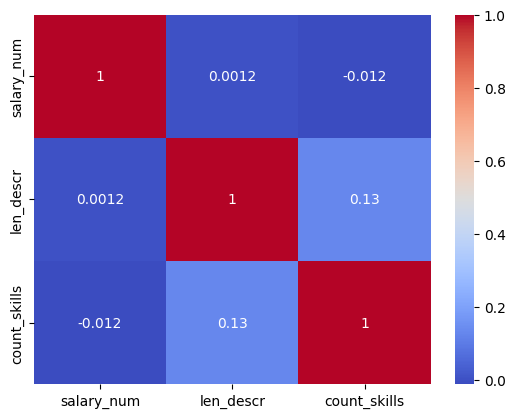

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation_table, annot=True, cmap='coolwarm')

plt.show()

18. Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов. **(3)**

19. Постройте гистограмму распределения зарплаты среди вакансий в рублях.  **(3)**

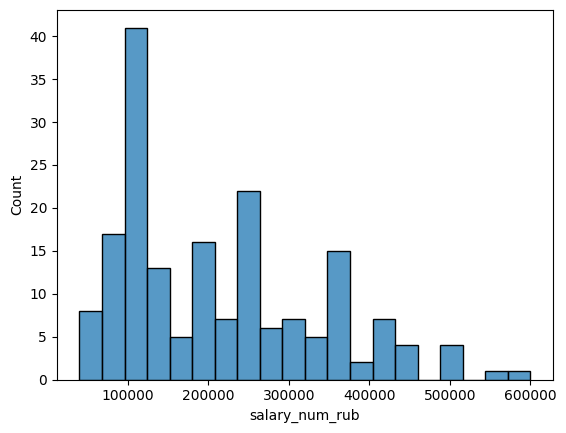

In [41]:
import ast
import seaborn as sns
import matplotlib.pyplot as pl

def calculate_salary_num(salary):
  if (pd.isnull(salary)):
    return None

  salary_dict: dict = ast.literal_eval(salary)
  if (salary_dict.get("currency")) != 'RUR':
    return None

  salary_from = salary_dict.get("from")
  salary_to = salary_dict.get("to")

  mean = None
  if (salary_from != 'null' and salary_to  != 'null'):
    mean = (float(salary_from) + float(salary_to)) / 2
  elif (salary_from  != 'null' and salary_to  == 'null'):
    mean = salary_from
  elif (salary_from  == 'null' and salary_to  != 'null'):
    mean = salary_to

  return mean

df['salary_num_rub'] = df['salary'].apply(calculate_salary_num).dropna()

sns.histplot(df['salary_num_rub'], bins=20)
plt.show()



20. Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience **(3)**

In [44]:
sns.boxplot(x='experience', y='salary_from_rub', data=df[df['salary_num_rub'].notna()])

ValueError: Could not interpret value `salary_from_rub` for `y`. An entry with this name does not appear in `data`.

21. Попробуйте ответить на какой-нибудь вопрос по данным, не заданный ранее. Никак не ограничиваем вашу фантазию **(3)**

## Задача 2. 55 баллов
Работаем с датасетом https://disk.yandex.ru/d/P6u1Za-nnmtwPA
Скачайте его.

Оцениваем факторы, которые влияют на цену на аренду в Москве.
Описание столбцов:

**metro** - ближайшая станция метро

**price** - цена за аренды


**minutes** - расстояние до метро в минутах

**way** - пусть до метро (пешком или на транспорте)

**views** - просмотры квартиры

**provider** - кто сдает квартиру (собственник, риелтор, застройщик)

**fee_percent** - процент, который получает риелтор

**storey**- этаж

**storeys**- число этажей в здании

**living_area** - жилая площаль

**kitchen_area** - площадь кухни

**total_area** - общая площадь


#### Часть 1. EDA. 30 баллов

In [ ]:
import pandas as pd
df = pd.read_csv('rent.csv', index_col=0)

,metro,price,way,views,provider,fee_percent,storey,minutes,storeys,living_area,kitchen_area,total_area
0,Planernaia,45000,walk,513,realtor,50,7,10,12,19,8,38
1,VDNKh,50000,walk,389,realtor,50,16,10,16,18,8,41
2,Alekseevskaia,50000,walk,483,realtor,50,5,3,12,19,5,33
3,Sviblovo,38000,walk,414,realtor,50,3,15,5,37,37,37
4,Rimskaia,55999,walk,360,realtor,99,6,7,17,21,10,40


1. Отобразите первые 5 и последние 5 строк. (**1**)

2. Посчитайте описательные статистики числовых переменных с помощью describe() (**1**)

3. Посчитайте статистики по категориальным переменным. Сколько уникальных значений у переменной metro? (**1**)

4. Есть ли в датасете пропуски? (**1**)

5. Есть ли в датасете полные дубликаты? (**2**)

6. Сколько уникальных значений у переменной provider? Есть ли со значениями этой переменной какие-нибудь проблемы? Если да, то как их исправить? (**3**)

> Ответ текстом

7. Постройте гистограммы распределения всех числовых переменных. Не забудьте подписать график и оси. (**2**)

 8. Напишите функцию, которая принимает на вход датасет, названия столбцов, название графика и осей и рисует scatter plot. Нариcуйте с её помощью не менее трёх scatterplot. (**4**)

9. Нарисуйте scatterplot всех пар переменных с помощью sns.pairplot. (**1**)

10. Нарисуйте boxplot переменной price. (**2**)

11. Нарисуйте еще какой-нибудь график, который считайте нужным. (**2**)

12. Какие выводы можно сделать из визуализаций 7-12? (**2**)

> Ответ текстом

13. Постройте таблицу корреляций и тепловую карту числовых переменных. Между какими переменными наблюдается линейная связь? (**3**)

> Ответ текстом

#### Часть 2. Построение модели. 30 баллов

1. Раздйлите датасет на обучающую и тестовую выборку. Постройте линейную регрессию для переменной price, используя только числовые переменные. Перед этим стандартизируйте все независимые переменные с помощью StandardScaler. (**5**)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as MSE,  root_mean_squared_error as RMSE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2. Сделайте прогноз, посчитайте MSE и RMSE модели на тестовой выборке (**5**)

3. Закодируйте переменные way	и	provider с помощью OneHotEncoding и добавьте их в модель. Обучите модель еще раз, посчитайте MSE и RMSE (**5**)

4. Удалите из обучающей выборке выбросы по цене (тестовую выборку не трогайте!) Выбросами считайте цены, которые дороже, чем $Q3+1.5 * IQR$, где $IQR$ - межквартильный размах, $Q3$ - 75 перцентиль. Обучите модель еще раз, посчитайте MSE и RMSE (**5**)

5. Попробуйте написать свою реализацию функций MSE и RMSE. Функции должна принимать на вход numpy-массив истинных значений и предсказаний и возвращать результат. Примените функции к предсказаниям последней модели. Сравните результат с библиотечной реализацией. (**6**)

Напоминаем, что

${MSE}=\frac{1}{n} \sum_{i=1}^n \left(y_i-\hat{y_i}\right)^2$, где $y_i$ - истинное значение на i-ом наблюдении, $\hat{y_i}$  - предсказание модели на i-ом наблюдении.

Также рекомендуем ознакомиться с документацией: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html

In [ ]:
def MSE(y_true, y_pred):
    # ваш код

    return mse

In [ ]:
def RMSE(y_true, y_pred):
    # ваш код

    return rmse

6. Попробуйте улучшить модель, добавив еще какое-нибудь преобразование (например, можете оставить только часть столбцов, добавить новые признаки, закодировать переменную metro и т.п.). Посчитайте метрики. Удалось ли улучшить модель? (**4**)

*Примечание. Любой разумный технически верно проведенный эксперимент
 засчитывается, даже если метрику улучшить не удалось.*